# Phase 2 — Data Preparation and Augmentation

**CSC3109 Machine Learning | Group 30**

Now that we understand our dataset (Phase 1), we prepare it for training.

## What This Phase Does

1. **Normalisation** — rescale pixel values to standard range
2. **Data Augmentation** — create variations of training images (flips, rotations, colour changes)
3. **DataLoaders** — PyTorch's batching and shuffling mechanism
4. **Visualisation** — show what augmented images look like

**Key insight:** Augmentation makes the model see more diversity in training data without needing more images. It prevents the model from overfitting to specific pixel patterns and instead learning general features.

---
## Step 0 — Imports

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print('All imports successful.')

PyTorch version: 2.6.0+cpu
CUDA available: False
All imports successful.


---
## Step 1 — Define Paths and Constants

In [2]:
REPO_ROOT = Path('..').resolve()
TRAIN_DIR = REPO_ROOT / 'data' / 'train'
VAL_DIR   = REPO_ROOT / 'data' / 'val'

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}

print(f'Train directory: {TRAIN_DIR}')
print(f'Val directory:   {VAL_DIR}')
print(f'Classes: {CLASS_NAMES}')
print(f'Class mapping: {CLASS_TO_IDX}')

Train directory: D:\csc3109 machine learning\csc3109 ml assignment\data\train
Val directory:   D:\csc3109 machine learning\csc3109 ml assignment\data\val
Classes: ['oil_well', 'solar_panel', 'transformer_station', 'wastewater_treatment_plant']
Class mapping: {'oil_well': 0, 'solar_panel': 1, 'transformer_station': 2, 'wastewater_treatment_plant': 3}


---
## Step 2 — Image Normalisation Transforms

**Normalisation** rescales pixel values from [0, 255] to approximately [-1, 1].

The values we use here are **ImageNet statistics** — the mean and std of 1.2 million everyday images. These work well for transfer learning because models pre-trained on ImageNet expect inputs in this range.

**Important:** We apply the SAME normalisation to both training and validation data. No augmentation on validation — we evaluate on unmodified images.

In [3]:
# ImageNet statistics (hardcoded because they're universal)
IMAGENET_MEAN = [0.485, 0.456, 0.406]  # R, G, B
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform for validation: resize and normalise ONLY (no augmentation)
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),  # resize to square; standard input size for transfer learning models
    transforms.ToTensor(),          # convert PIL Image → torch tensor, pixel range [0, 1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # normalise
])

print('Validation transform:')
print('  1. Resize to 224×224')
print('  2. Convert to tensor')
print('  3. Normalise using ImageNet statistics')
print('  (No augmentation — we evaluate on clean images)')

Validation transform:
  1. Resize to 224×224
  2. Convert to tensor
  3. Normalise using ImageNet statistics
  (No augmentation — we evaluate on clean images)


---
## Step 3 — Data Augmentation for Training

**Data augmentation** creates variations of training images at runtime. This helps the model generalise to variations it hasn't seen.

We apply augmentation **only to the training set**, never to validation.

### Augmentation Strategy

| Transform | What it does | Probability | Why |
|-----------|----------|-------------|-----|
| RandomHorizontalFlip | Flip left-right | 0.5 | Aerial images can be viewed from any angle |
| RandomRotation | Rotate ±20° | 100% | Objects in aerial view can be rotated |
| ColorJitter | Vary brightness/contrast/saturation | 100% | Lighting conditions vary |
| RandomAffine | Shear and translate | 100% | Perspective varies with altitude |

Together, these ensure the model sees rich variations without overfitting to the exact pixel layout of the original 700 training images.

In [4]:
# Transform for training: augmentation + normalisation
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    
    # Augmentation (training only)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    
    # Normalisation (same as validation)
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Training transform (includes augmentation):')
print('  1. Resize to 224×224')
print('  2. [AUG] Random horizontal flip (50%)')
print('  3. [AUG] Random rotation (±20°)')
print('  4. [AUG] Random colour jitter (brightness, contrast, saturation, hue)')
print('  5. [AUG] Random affine transform (translation, shear)')
print('  6. Convert to tensor')
print('  7. Normalise using ImageNet statistics')

Training transform (includes augmentation):
  1. Resize to 224×224
  2. [AUG] Random horizontal flip (50%)
  3. [AUG] Random rotation (±20°)
  4. [AUG] Random colour jitter (brightness, contrast, saturation, hue)
  5. [AUG] Random affine transform (translation, shear)
  6. Convert to tensor
  7. Normalise using ImageNet statistics


---
## Step 4 — Visualise Augmentation Effects

Here we load one real image and show what it looks like after different random augmentations. This helps us verify that augmentation is sensible (not too aggressive, not too weak).

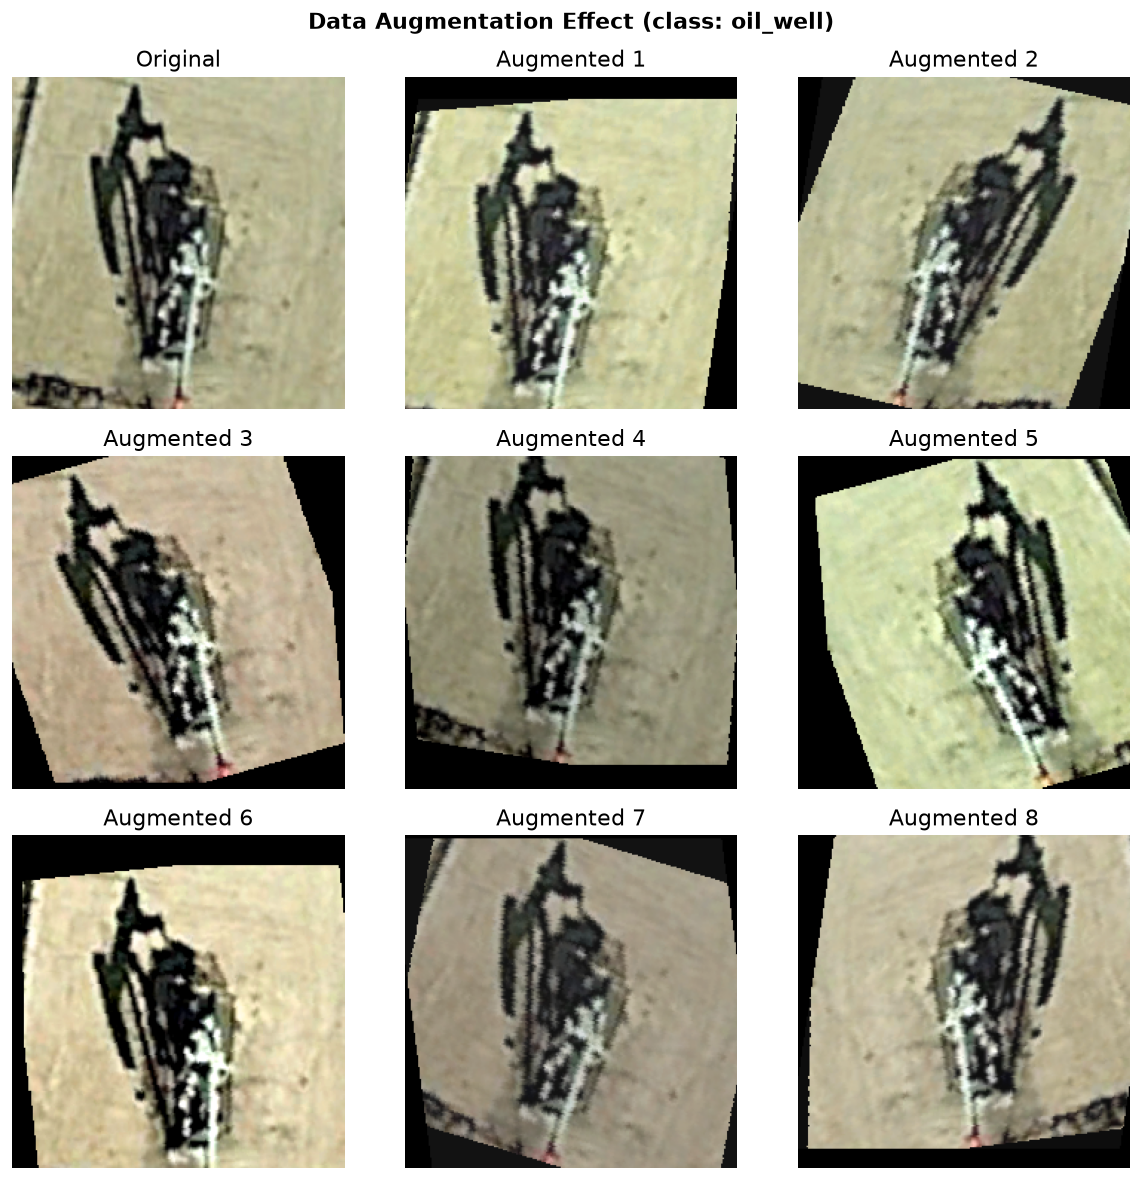

Saved: report/augmentation_examples.png


In [5]:
# Pick a random training image
sample_cls = CLASS_NAMES[0]
sample_path = sorted((TRAIN_DIR / sample_cls).iterdir())[0]
img = Image.open(sample_path).convert('RGB')

# Show original and 8 augmented versions
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle(f'Data Augmentation Effect (class: {sample_cls})', fontsize=13, fontweight='bold')

# Plot original
axes[0, 0].imshow(img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Plot 8 augmented versions
for idx in range(1, 9):
    row = idx // 3
    col = idx % 3
    
    # Apply augmentation (normalize and convert to tensor for display)
    # We show the augmented image before normalisation to keep colours visible
    aug_only = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    ])
    img_aug = aug_only(img)
    axes[row, col].imshow(img_aug)
    axes[row, col].set_title(f'Augmented {idx}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('../report/augmentation_examples.png', bbox_inches='tight')
plt.show()
print('Saved: report/augmentation_examples.png')

---
## Step 5 — PyTorch ImageDataset Class

This is the core of data loading. `ImageDataset` inherits from `torch.utils.data.Dataset` and tells PyTorch:

- How many images there are (`__len__`)
- How to load an image by index (`__getitem__`)
- What transforms to apply

PyTorch uses this to create batches automatically.

In [6]:
class ImageDataset(Dataset):
    """Load aerial images and apply transforms.
    
    Args:
        root_dir (Path): path to directory with class subdirectories
        transform (callable): torchvision.transforms.Compose to apply
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        
        # Build a list of (image_path, class_label) tuples
        self.samples = []
        for cls_name in sorted(self.root_dir.iterdir()):
            if not cls_name.is_dir():
                continue
            class_idx = CLASS_TO_IDX[cls_name.name]
            for img_path in cls_name.iterdir():
                if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}:
                    self.samples.append((img_path, class_idx))
        
        print(f'Loaded {len(self.samples)} images from {root_dir}')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

print('ImageDataset class defined.')

ImageDataset class defined.


---
## Step 6 — Create Datasets

In [7]:
# Create dataset objects
train_dataset = ImageDataset(root_dir=TRAIN_DIR, transform=transform_train)
val_dataset   = ImageDataset(root_dir=VAL_DIR,   transform=transform_val)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Val dataset size:   {len(val_dataset)}')

Loaded 2400 images from D:\csc3109 machine learning\csc3109 ml assignment\data\train
Loaded 400 images from D:\csc3109 machine learning\csc3109 ml assignment\data\val
Train dataset size: 2400
Val dataset size:   400


---
## Step 7 — Create DataLoaders

A `DataLoader` wraps the dataset and handles:
- **Batching:** group 32 images into a batch
- **Shuffling:** randomise order each epoch (training only)
- **Parallel loading:** load images in background threads

This is what the training loop will iterate over.

In [8]:
BATCH_SIZE = 32
NUM_WORKERS = 0  # set to 0 on Windows; can be 4+ on Linux/Mac for faster loading

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,      # shuffle at start of each epoch
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,     # no need to shuffle validation
    num_workers=NUM_WORKERS
)

print(f'Train batches per epoch: {len(train_loader)}')
print(f'Val batches:             {len(val_loader)}')
print(f'Batch size:              {BATCH_SIZE}')

Train batches per epoch: 75
Val batches:             13
Batch size:              32


---
## Step 8 — Test DataLoaders

We load one batch to verify everything works and shapes are correct.

In [9]:
# Get one batch from train loader
images, labels = next(iter(train_loader))

print(f'Batch shape (images): {tuple(images.shape)}')
print(f'  → (batch_size=32, channels=3, height=224, width=224)')
print(f'Batch shape (labels):  {tuple(labels.shape)}')
print(f'  → (batch_size=32,)')
print(f'\nLabel values (class indices): {labels.unique().tolist()}')
print(f'Pixel value range (normalised): [{images.min():.2f}, {images.max():.2f}]')

Batch shape (images): (32, 3, 224, 224)
  → (batch_size=32, channels=3, height=224, width=224)
Batch shape (labels):  (32,)
  → (batch_size=32,)

Label values (class indices): [0, 1, 2, 3]
Pixel value range (normalised): [-2.12, 2.64]


---
## Step 9 — Visualise a Batch

We display one batch to make sure images look reasonable after normalisation and augmentation.

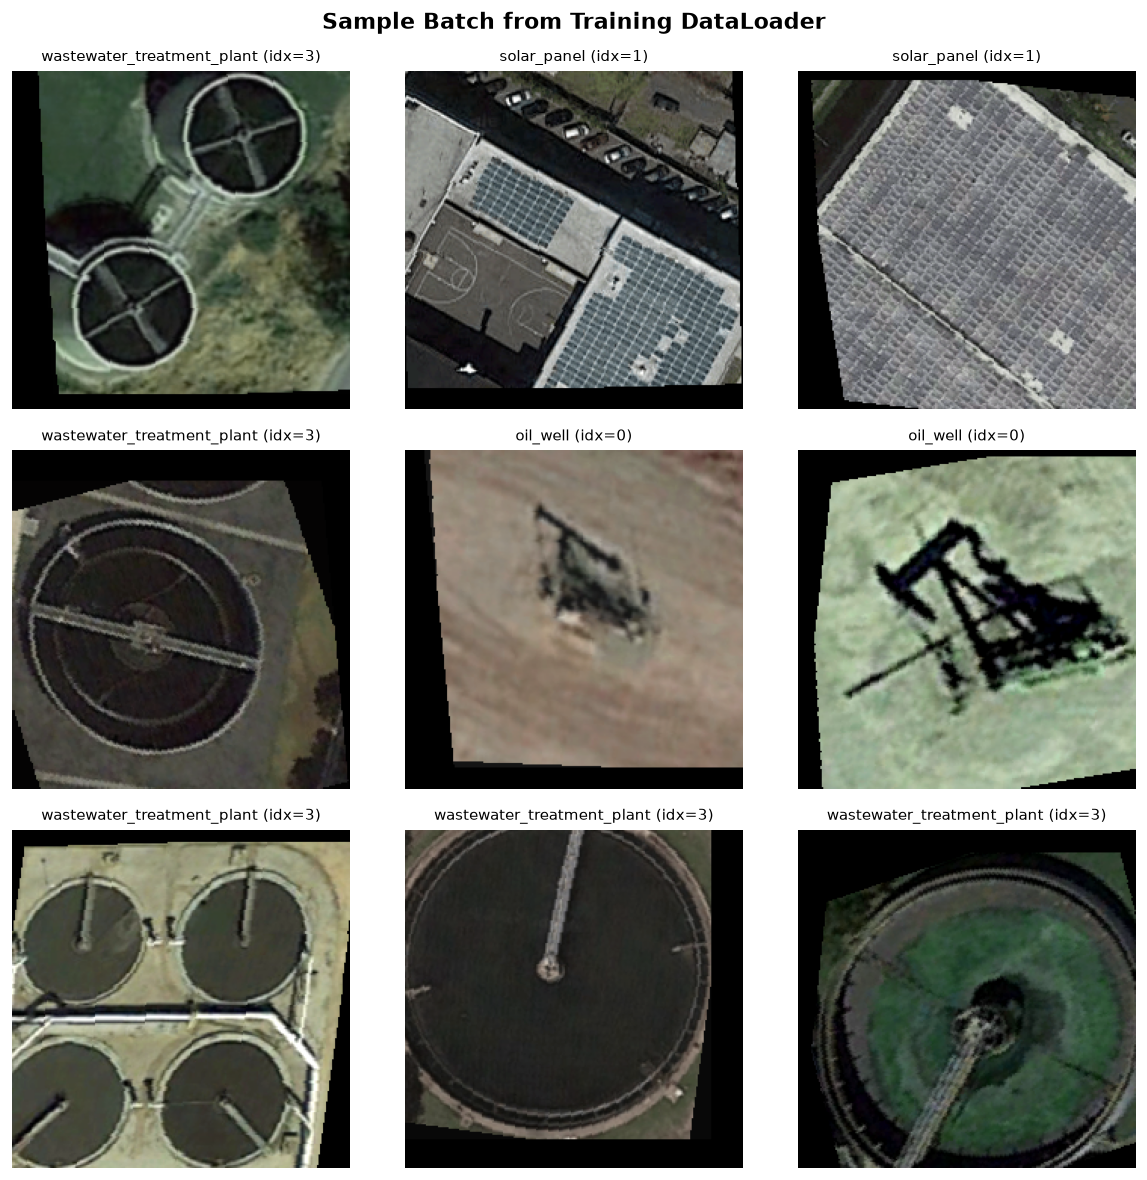

Saved: report/batch_visualization.png


In [10]:
# Undo normalisation for visualization
def denormalise(tensor):
    """Convert normalised tensor back to [0, 1] for display."""
    tensor = tensor.clone()
    for i, (mean, std) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
        tensor[i] = tensor[i] * std + mean
    return torch.clamp(tensor, 0, 1)

# Plot 9 images from the batch
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Sample Batch from Training DataLoader', fontsize=13, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    img = denormalise(images[idx]).permute(1, 2, 0).numpy()
    label = labels[idx].item()
    class_name = IDX_TO_CLASS[label]
    
    ax.imshow(img)
    ax.set_title(f'{class_name} (idx={label})', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../report/batch_visualization.png', bbox_inches='tight')
plt.show()
print('Saved: report/batch_visualization.png')

---
## Step 10 — Save DataLoader Setup as a Module

We save the `ImageDataset` class and transform definitions to `src/dataset.py` so the training code can reuse them.

This keeps code DRY (Don't Repeat Yourself) — we define the transforms once, use them everywhere.

In [11]:
dataset_code = '''"""PyTorch Dataset and DataLoader setup for aerial imagery classification."""

from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ImageNet normalisation (standard for transfer learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Class names (must match directory structure)
CLASS_NAMES = ['oil_well', 'solar_panel', 'transformer_station', 'wastewater_treatment_plant']
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

# Transform definitions
TRANSFORM_VAL = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

TRANSFORM_TRAIN = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


class ImageDataset(Dataset):
    """Load aerial images from a directory with class subdirectories."""

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        # Collect all image paths
        for cls_dir in sorted(self.root_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            class_idx = CLASS_TO_IDX.get(cls_dir.name)
            if class_idx is None:
                continue

            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in {\'.jpg\', \'.jpeg\', \'.png\', \'.bmp\', \'.tiff\'}:
                    self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert(\'RGB\')
        if self.transform:
            img = self.transform(img)
        return img, label


def get_data_loaders(data_dir, batch_size=32, num_workers=0):
    """Create train and validation DataLoaders.

    Args:
        data_dir (Path): path to directory containing \'train\' and \'val\' subdirs
        batch_size (int): images per batch
        num_workers (int): parallel processes for loading (0 on Windows)

    Returns:
        (train_loader, val_loader, class_to_idx, idx_to_class)
    """
    data_dir = Path(data_dir)
    train_dir = data_dir / \'train\'
    val_dir = data_dir / \'val\'

    train_dataset = ImageDataset(train_dir, transform=TRANSFORM_TRAIN)
    val_dataset = ImageDataset(val_dir, transform=TRANSFORM_VAL)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    return train_loader, val_loader, CLASS_TO_IDX, IDX_TO_CLASS
'''

# Write to src/dataset.py
src_dir = Path('..') / 'src'
src_dir.mkdir(parents=True, exist_ok=True)
(src_dir / 'dataset.py').write_text(dataset_code)

print('Saved: src/dataset.py')
print('This module can now be imported by training scripts:')
print('  from src.dataset import get_data_loaders')

Saved: src/dataset.py
This module can now be imported by training scripts:
  from src.dataset import get_data_loaders


---
## Step 11 — Verify the Module Works

We test that the saved module can be imported and used.

In [12]:
# Add src to path so we can import our module
import sys
sys.path.insert(0, str(Path('..') / 'src'))

from dataset import get_data_loaders

# Test the function
train_loader, val_loader, cls2idx, idx2cls = get_data_loaders(
    data_dir=Path('..') / 'data',
    batch_size=32,
    num_workers=0
)

print(f'Successfully loaded from src/dataset.py')
print(f'Train loader batches: {len(train_loader)}')
print(f'Val loader batches:   {len(val_loader)}')
print(f'Class mapping: {cls2idx}')

Successfully loaded from src/dataset.py
Train loader batches: 75
Val loader batches:   13
Class mapping: {'oil_well': 0, 'solar_panel': 1, 'transformer_station': 2, 'wastewater_treatment_plant': 3}


---
## Phase 2 Complete

**Deliverables:**
- ✅ `src/dataset.py` — reusable DataLoader setup module
- ✅ `report/augmentation_examples.png` — visualisation of augmentation effects
- ✅ `report/batch_visualization.png` — sample batch from DataLoader

**Key takeaways:**
- Normalisation: rescale pixel values to [-1, 1] using ImageNet statistics
- Augmentation: apply random transforms ONLY to training data
- DataLoaders: batch, shuffle, and efficiently load images
- `ImageDataset`: reusable class for loading images with transforms

**Next:** Phase 3 — Deep Learning Approaches (`notebooks/03a_custom_cnn.ipynb`)